Preparation des données


In [1]:
import pandas as pd
df = pd.read_csv("allocinejpboxv4.csv")


In [2]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10175 entries, 0 to 10174
Data columns (total 50 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              10175 non-null  int64  
 1   title                           10175 non-null  object 
 2   original_title                  3948 non-null   object 
 3   release_date                    10175 non-null  object 
 4   duration                        10175 non-null  float64
 5   genres                          10175 non-null  object 
 6   press_rating                    10175 non-null  float64
 7   audience_rating                 10175 non-null  float64
 8   director                        9808 non-null   object 
 9   writer                          9808 non-null   object 
 10  audience                        1492 non-null   object 
 11  distributor                     10175 non-null  object 
 12  movie_type                      

In [3]:
print(df.describe())


                 id      duration  press_rating  audience_rating  \
count  10175.000000  10175.000000  10175.000000     10175.000000   
mean    5088.000000    102.950049      3.067464         3.008576   
std     2937.413829     20.799016      0.641401         0.638668   
min        1.000000     24.000000      1.000000         0.800000   
25%     2544.500000     91.000000      2.700000         2.600000   
50%     5088.000000    100.000000      3.100000         3.008576   
75%     7631.500000    112.000000      3.500000         3.500000   
max    10175.000000    543.000000      5.000000         4.500000   

       box_office_fr  box_office_us       film_id  realisateur_id  \
count   1.017500e+04   1.017500e+04   5493.000000     1355.000000   
mean    1.276743e+05   5.676488e+06  13531.729838      526.479705   
std     2.848556e+05   1.705749e+07   7294.230587      284.166752   
min     0.000000e+00   0.000000e+00      7.000000       10.000000   
25%     2.131000e+03   0.000000e+00  10448

In [5]:
df.isnull().sum()


id                                   0
title                                0
original_title                    6227
release_date                         0
duration                             0
genres                               0
press_rating                         0
audience_rating                      0
director                           367
writer                             367
audience                          8683
distributor                          0
movie_type                           0
nationality                          7
languages                            0
synopsis                            40
actors                             150
box_office_fr                        0
box_office_us                        0
image_url                            0
film_id                           4682
realisateur_id                    8820
rang                              4682
titre_x                           4682
titre_vo                          8820
realisateur              

In [6]:
df.columns

Index(['id', 'title', 'original_title', 'release_date', 'duration', 'genres',
       'press_rating', 'audience_rating', 'director', 'writer', 'audience',
       'distributor', 'movie_type', 'nationality', 'languages', 'synopsis',
       'actors', 'box_office_fr', 'box_office_us', 'image_url', 'film_id',
       'realisateur_id', 'rang', 'titre_x', 'titre_vo', 'realisateur', 'genre',
       'annee', 'pays', 'entrees', 'salles', 'moy_salle', 'part_marche',
       'affiche', 'moyenne_fr_realisateur', 'sortie', 'distributeur',
       'classification', 'acteurs', 'moyennes_individuelles_acteurs',
       'acteurs principal', 'acteurs secondaires', 'max_moyenne',
       'moyennebestactors', 'Pays', 'cluster_realisateur',
       'cluster_acteur_principal', 'cluster_acteur_secondaire', 'titre_y',
       'budget'],
      dtype='object')

In [8]:
df = df.drop(columns=["titre_y", "id", "press_rating", "audience_rating", "synopsis", "titre_x", "titre_vo", "film_id", "affiche", "synopsis", "realisateur_id", "rang", "moy_salle", "part_marche", "image_url"])

In [9]:
df.columns

Index(['title', 'original_title', 'release_date', 'duration', 'genres',
       'director', 'writer', 'audience', 'distributor', 'movie_type',
       'nationality', 'languages', 'actors', 'box_office_fr', 'box_office_us',
       'realisateur', 'genre', 'annee', 'pays', 'entrees', 'salles',
       'moyenne_fr_realisateur', 'sortie', 'distributeur', 'classification',
       'acteurs', 'moyennes_individuelles_acteurs', 'acteurs principal',
       'acteurs secondaires', 'max_moyenne', 'moyennebestactors', 'Pays',
       'cluster_realisateur', 'cluster_acteur_principal',
       'cluster_acteur_secondaire', 'budget'],
      dtype='object')

In [10]:
# Suppression des lignes en place
df.drop(df[df['box_office_fr'] == 0.0].index, inplace=True)


In [29]:
df.shape[0]

9263

In [30]:
df.head(5)

,title,original_title,release_date,duration,genres,director,writer,audience,distributor,movie_type,...,acteurs principal,acteurs secondaires,max_moyenne,moyennebestactors,Pays,cluster_realisateur,cluster_acteur_principal,cluster_acteur_secondaire,budget,release date
0,Monsieur Constant,NaN,2025-05-28,108.000000,Comédie dramatique,alan simon,Alan Simon,NaN,Émotions Distribution,Long métrage,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-05-28
3,Notes Laura Fiori,NaN,2025-04-15,75.000000,Drame,NaN,NaN,NaN,Cinéma Saint-André des Arts,Long métrage,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-04-15
4,Trois contes,NaN,2025-04-14,102.950049,Animation,NaN,NaN,NaN,Diaphana Distribution,Long métrage,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-04-14
12,La Dame du jeu,NaN,2025-04-14,86.000000,Comédie dramatique,NaN,NaN,NaN,-,Long métrage,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-04-14
14,"Napoléon, 2ème partie",NaN,2025-04-14,102.950049,Divers,NaN,NaN,NaN,-,Long métrage,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-04-14


In [32]:
import pandas as pd

# Assurez-vous que "release date" est au format datetime et supprimez les heures
df['release_date'] = pd.to_datetime(df['release_date']).dt.date

# Définir les limites de date en format "date" (sans heures)
start_date = pd.to_datetime('2000-01-01').date()  # Début : janvier 2000 inclus
end_date = pd.to_datetime('2025-03-31').date()   # Fin : mars 2025 inclus

# Filtrer les lignes dans la plage de dates
df_filtered = df[(df['release_date'] >= start_date) & (df['release_date'] <= end_date)]

print(df_filtered)



                      title   original_title release_date  duration  \
53                     Anna              NaN   2025-03-05     118.0   
54                Black Dog         Gou Zhen   2025-03-05     110.0   
55      Le Secret de Khéops              NaN   2025-03-05      98.0   
56                Mickey 17              NaN   2025-03-05     137.0   
57                    Eject              NaN   2025-03-05     109.0   
...                     ...              ...          ...       ...   
10166           Chicken Run              NaN   2000-12-13      84.0   
10167             Dinosaure         Dinosaur   2000-11-29      82.0   
10168  In the Mood for Love  Fa yeung nin wa   2000-11-08      98.0   
10172    Le goût des autres              NaN   2000-03-01     112.0   
10174          Sixième Sens  The Sixth Sense   2000-01-05     107.0   

                                genres                      director  \
53                               Drame                  marco amenta   
54 

In [35]:
df_filtered.shape[0]

9254

In [33]:
df_filtered.head(5)

,title,original_title,release_date,duration,genres,director,writer,audience,distributor,movie_type,...,acteurs principal,acteurs secondaires,max_moyenne,moyennebestactors,Pays,cluster_realisateur,cluster_acteur_principal,cluster_acteur_secondaire,budget,release date
53,Anna,NaN,2025-03-05,118.0,Drame,marco amenta,"Marco Amenta,Anna Mittone",Tout public,Les Films de l'Atalante,Long métrage,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-03-05
54,Black Dog,Gou Zhen,2025-03-05,110.0,Drame,hu guan,"Hu Guan,Rui Ge",Tout public,Memento,Long métrage,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-03-05
55,Le Secret de Khéops,NaN,2025-03-05,98.0,Aventure,barbara schulz,"Barbara Schulz,Christophe Turpin",Tout public,SND,Long métrage,...,Fabrice Luchini,NaN,783947.0,7.839470e+05,NaN,NaN,1,NaN,NaN,2025-03-05
56,Mickey 17,NaN,2025-03-05,137.0,"Action,Comédie,""Science Fiction",bong joon ho,Bong Joon Ho,Tout public avec avertissement,Warner Bros. France,Long métrage,...,Robert Pattinson,"Toni Collette, Mark Ruffalo",1913382.0,1.216790e+06,NaN,NaN,2,"0, 1",NaN,2025-03-05
57,Eject,NaN,2025-03-05,109.0,Drame,tiburce,Tiburce,NaN,Thaumatrope Film Association - CFA Programmation,Long métrage,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-03-05


In [36]:
# Filtrer pour ne conserver que les lignes où 'max_moyenne' n'est pas vide (non-NaN)
df = df_filtered[df_filtered['max_moyenne'].notna()]


In [38]:
df.shape[0]

3583

In [44]:
df.to_csv('xgboost.csv', index=False)

In [39]:
df.head(10)

,title,original_title,release_date,duration,genres,director,writer,audience,distributor,movie_type,...,acteurs principal,acteurs secondaires,max_moyenne,moyennebestactors,Pays,cluster_realisateur,cluster_acteur_principal,cluster_acteur_secondaire,budget,release date
55,Le Secret de Khéops,NaN,2025-03-05,98.0,Aventure,barbara schulz,"Barbara Schulz,Christophe Turpin",Tout public,SND,Long métrage,...,Fabrice Luchini,NaN,783947.0,7.839470e+05,NaN,NaN,1,NaN,NaN,2025-03-05
56,Mickey 17,NaN,2025-03-05,137.0,"Action,Comédie,""Science Fiction",bong joon ho,Bong Joon Ho,Tout public avec avertissement,Warner Bros. France,Long métrage,...,Robert Pattinson,"Toni Collette, Mark Ruffalo",1913382.0,1.216790e+06,NaN,NaN,2,"0, 1",NaN,2025-03-05
58,In The Lost Lands,NaN,2025-03-05,101.0,"Action,Aventure,Fantastique",paul w.s. anderson,"Paul W.S. Anderson,Constantin Werner",Interdit - 12 ans,Metropolitan FilmExport,Long métrage,...,Milla Jovovich,NaN,778222.0,7.782220e+05,Canada,1.0,1,NaN,NaN,2025-03-05
68,A Real Pain,NaN,2025-02-26,89.0,Comédie dramatique,jesse eisenberg,Jesse Eisenberg,Tout public,The Walt Disney Company France,Long métrage,...,Jesse Eisenberg,NaN,792849.0,7.928490e+05,Etats-Unis,NaN,1,NaN,3000000.0,2025-02-26
69,Queer,NaN,2025-02-26,136.0,Comédie dramatique,luca guadagnino,Justin Kuritzkes,Interdit - 12 ans avec avertissement,Pan Distribution,Long métrage,...,Daniel Craig,NaN,1176613.0,1.176613e+06,Etats-Unis,NaN,0,NaN,48000000.0,2025-02-26
74,The Monkey,NaN,2025-02-19,98.0,"Comédie,Epouvante-horreur",osgood perkins,Osgood Perkins,Interdit - 12 ans,Metropolitan FilmExport,Long métrage,...,Elijah Wood,NaN,1225316.0,1.225316e+06,Etats-Unis,NaN,0,NaN,NaN,2025-02-19
75,Mercato,NaN,2025-02-19,119.0,"Comédie dramatique"",Thriller",tristan séguéla,"Olivier Demangel,Thomas Finkielkraut",Tout public,Pathé Films,Long métrage,...,Jamel Debbouze,NaN,2206954.0,2.206954e+06,France,NaN,2,NaN,NaN,2025-02-19
80,Dis-moi juste que tu m'aimes,NaN,2025-02-19,111.0,Drame,anne le ny,Anne Le Ny,Tout public,SND,Long métrage,...,"Elodie Bouchez, José Garcia, Vanessa Paradis, ...",NaN,1790053.0,1.156922e+06,France,NaN,"0, 1, 2",NaN,NaN,2025-02-19
83,Bridget Jones : folle de lui,Bridget Jones: Mad About the Boy,2025-02-12,124.0,"Comédie,Romance",michael morris,"Helen Fielding,Abi Morgan",Tout public,StudioCanal,Long métrage,...,Renee Zellweger,"Colin Firth, Hugh Grant, Emma Thompson",990806.0,9.012037e+05,Grande-Bretagne,NaN,1,"0, 1",NaN,2025-02-12
87,The Brutalist,NaN,2025-02-12,214.0,Drame,brady corbet,"Brady Corbet,Mona Fastvold",Tout public avec avertissement,Universal Pictures International France,Long métrage,...,"Adrien Brody, Guy Pearce",NaN,762495.0,6.859305e+05,Grande-Bretagne,NaN,1,NaN,9600000.0,2025-02-12


In [40]:
df_budget = df[df['budget'].notna()]
df_budget.shape[0]


1779

In [41]:
# Compter le nombre de réalisateurs différents dans la colonne 'director'
nombre_directeurs_uniques = df['director'].nunique()

print(f"Nombre de réalisateurs différents : {nombre_directeurs_uniques}")


Nombre de réalisateurs différents : 1983


In [42]:
nombre_de_distributeurs_uniques = df['distributeur'].nunique()
print(f"Nombre de distributeurs différents : {nombre_de_distributeurs_uniques}")

Nombre de distributeurs différents : 105


In [43]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor, XGBClassifier  # selon si c'est une régression ou classification
import matplotlib.pyplot as plt
import seaborn as sns


In [56]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor  # puisque nous allons prédire "box_office_fr" (régression)
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

# Charger le dataset
data = pd.read_csv("xgboost.csv")  # remplacez par le chemin vers votre fichier


In [57]:
# Après avoir filtré pour conserver uniquement les colonnes utiles
colonnes_utiles = [
    'title', 
    'release_date', 
    'duration', 
    'distributor', 
    'movie_type', 
    'languages', 
    'audience', 
    'Pays', 
    'max_moyenne', 
    'cluster_acteur_principal', 
    'budget',
    'box_office_fr'
]
data = data[colonnes_utiles].copy()  # Création d'une copie explicite du DataFrame



In [58]:
data["release_date"] = pd.to_datetime(data["release_date"], errors='coerce')
data["release_year"] = data["release_date"].dt.year
data["release_month"] = data["release_date"].dt.month
data["release_day"] = data["release_date"].dt.day
data.drop(columns=["release_date"], inplace=True)


In [59]:
# Remplir les valeurs manquantes par la médiane pour les variables numériques
numeric_cols = ["duration", "max_moyenne", "budget"]
for col in numeric_cols:
    data[col].fillna(data[col].median(), inplace=True)


/tmp/ipykernel_28803/3761907794.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].median(), inplace=True)
/tmp/ipykernel_28803/3761907794.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

In [61]:
# Ajouter "audience" à la liste des features catégorielles
categorical_features = ["distributor", "movie_type", "languages", "Pays", "cluster_acteur_principal", "audience"]

# Encodage One-Hot de toutes ces colonnes et suppression de la première modalité pour éviter la redondance
data = pd.get_dummies(data, columns=categorical_features, drop_first=True)


In [74]:
# Supposons que nous utilisons maintenant toutes les colonnes préparées sauf "box_office_fr" (et éventuellement "title")
X = data.drop(columns=["box_office_fr", "title"])  # on peut supprimer "title" si on a extrait "title_length"
y = data["box_office_fr"]

import numpy as np


y = np.log1p(y)  # Utilisation de log1p pour gérer les valeurs proches de 0



In [75]:
from xgboost import XGBRegressor

model = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)


In [76]:
print(X.dtypes)
print("Colonnes de type object :", X.select_dtypes(include=["object"]).columns.tolist())


duration                                         float64
max_moyenne                                      float64
budget                                           float64
release_year                                       int32
release_month                                      int32
                                                  ...   
audience_Interdit - 16 ans                          bool
audience_Interdit - 16 ans avec avertissement       bool
audience_Interdit - 18 ans                          bool
audience_Tout public                                bool
audience_Tout public avec avertissement             bool
Length: 435, dtype: object
Colonnes de type object : []


In [77]:
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

# Définir 5 folds en mélangeant les données
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Utiliser cross_val_score pour obtenir les scores négatifs de MSE
scores = cross_val_score(model, X, y, scoring="neg_mean_squared_error", cv=cv)

print("Scores négatifs de MSE pour chaque fold :", scores)
print("Score MSE moyen :", -np.mean(scores))
print("RMSE moyen :", np.sqrt(-np.mean(scores)))


Scores négatifs de MSE pour chaque fold : [-1.41410381 -1.59045562 -1.38403622 -1.3109855  -1.36215959]
Score MSE moyen : 1.4123481486725917
RMSE moyen : 1.1884225463498208


count    3.583000e+03
mean     2.303942e+05
std      3.384534e+05
min      4.000000e+01
25%      4.716400e+04
50%      1.179150e+05
75%      2.639330e+05
max      3.426471e+06
Name: box_office_fr, dtype: float64


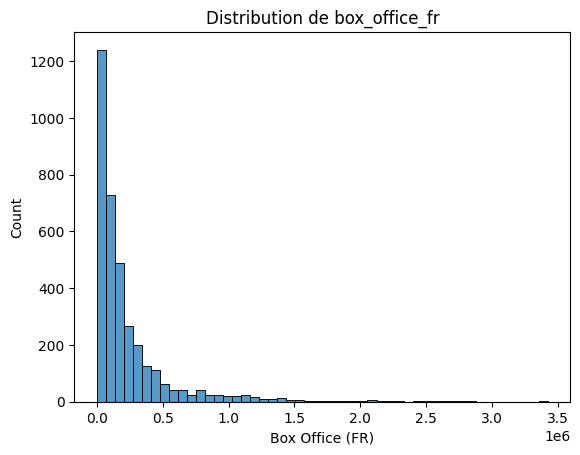

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

print(y.describe())
sns.histplot(y, bins=50)
plt.xlabel("Box Office (FR)")
plt.title("Distribution de box_office_fr")
plt.show()


In [78]:
from sklearn.model_selection import train_test_split

# Séparer les données en ensemble d'entraînement (80 %) et de test (20 %)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [80]:
model.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [81]:
# Prédictions sur l'échelle logarithmique
predictions_log = model.predict(X_test)

# Inverser la transformation logarithmique pour revenir à l'échelle originale
predictions_original = np.expm1(predictions_log)


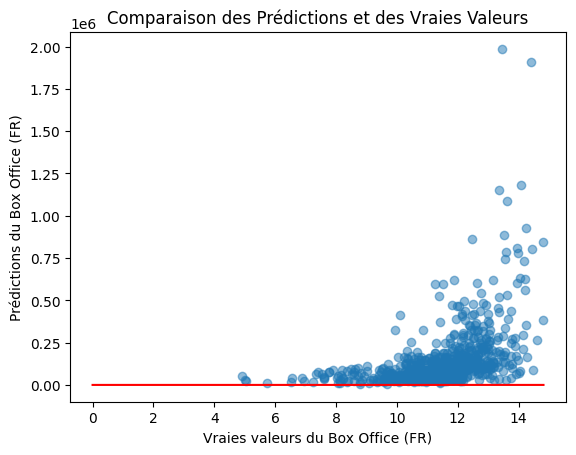

In [82]:
import matplotlib.pyplot as plt

plt.scatter(y_test, predictions_original, alpha=0.5)
plt.xlabel("Vraies valeurs du Box Office (FR)")
plt.ylabel("Prédictions du Box Office (FR)")
plt.title("Comparaison des Prédictions et des Vraies Valeurs")
plt.plot([0, max(y_test)], [0, max(y_test)], color='red')  # Ligne de référence y=x
plt.show()


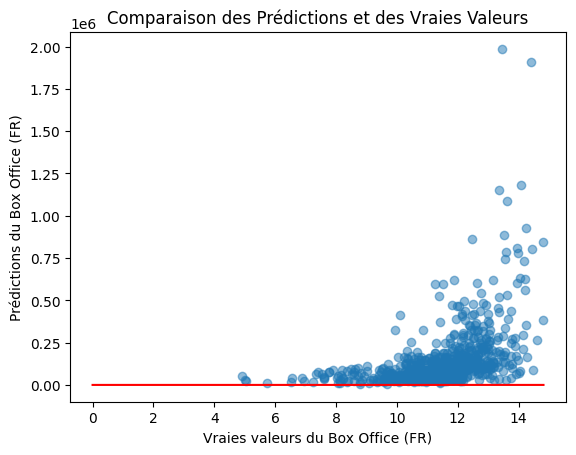

In [83]:
import matplotlib.pyplot as plt

# Prédictions inversées (revenir à l'échelle originale)
predictions_log = model.predict(X_test)
predictions_original = np.expm1(predictions_log)

# Comparaison entre les vraies valeurs et les prédictions
plt.scatter(y_test, predictions_original, alpha=0.5)
plt.xlabel("Vraies valeurs du Box Office (FR)")
plt.ylabel("Prédictions du Box Office (FR)")
plt.title("Comparaison des Prédictions et des Vraies Valeurs")
plt.plot([0, max(y_test)], [0, max(y_test)], color='red')  # Ligne y=x pour référence
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculer les erreurs
errors = y_test - predictions

sns.histplot(errors, bins=50, kde=True)
plt.xlabel("Erreur (Box Office réel - Prédiction)")
plt.title("Distribution des Erreurs")
plt.show()


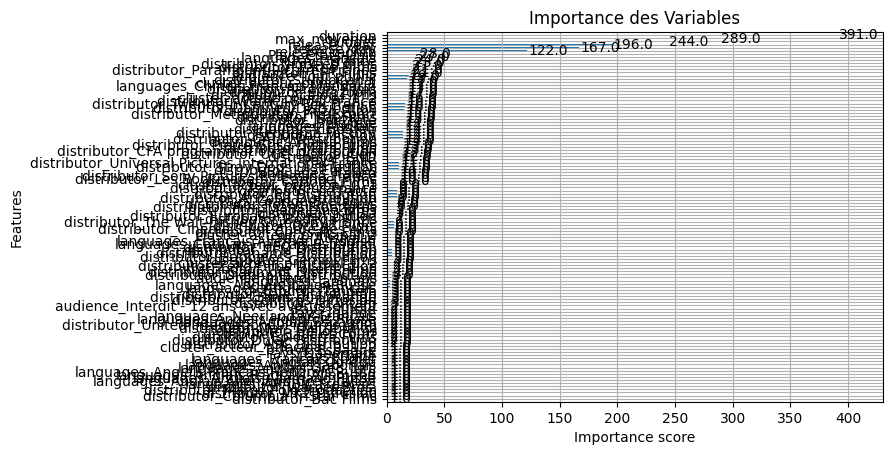

In [84]:
from xgboost import plot_importance

plot_importance(model)
plt.title("Importance des Variables")
plt.show()


/home/maxime/DataDevIA/predictioncinema/popularity_movie_prediction_project/ML/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


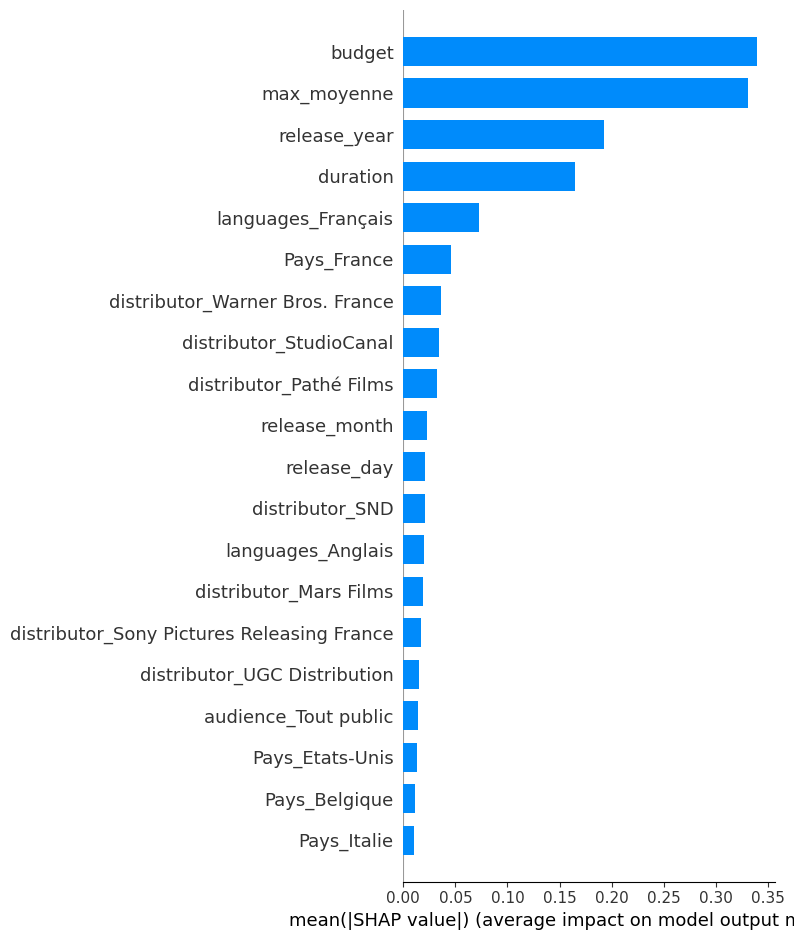

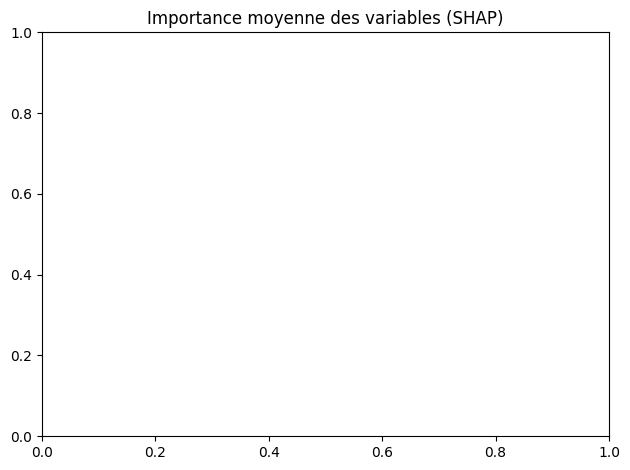

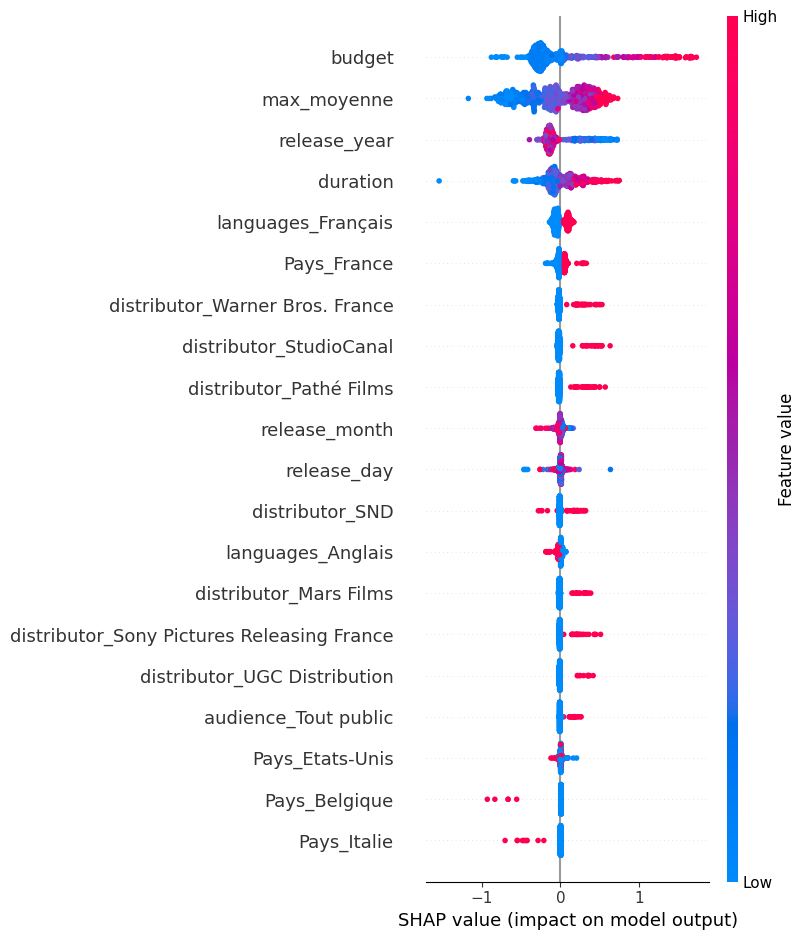

In [85]:
import shap
import matplotlib.pyplot as plt

# 1. Créer l'explainer SHAP pour votre modèle XGBoost
explainer = shap.TreeExplainer(model)

# 2. Calculer les valeurs SHAP sur l'ensemble des données de test
shap_values = explainer.shap_values(X_test)

# 3. Visualiser l'importance moyenne des variables avec un summary plot de type bar
shap.summary_plot(shap_values, X_test, plot_type="bar")
plt.title("Importance moyenne des variables (SHAP)")
plt.tight_layout()
plt.show()

# 4. Visualiser la distribution des impacts SHAP avec un summary plot (beeswarm)
shap.summary_plot(shap_values, X_test)
